# Load Best Parameter

In [68]:
import json 
import os
import numpy as np 

path = "./folder_results_mnist_results_20260518_011639/"

files = os.listdir(path=path)

print(files)

json_file = None

with open(os.path.join(path, "model_results.json"), 'r', encoding='utf-8') as f:
    json_file = json.load(f)

['neural-9-weights.npz', 'conv2d-1-bias.npz', 'conv2d-3-weights.npz', 'conv2d-3-bias.npz', 'model_results.json', 'conv2d-5-weights.npz', 'neural-8-bias.npz', 'conv2d-1-weights.npz', 'neural-8-weights.npz', 'neural-9-bias.npz', 'conv2d-5-bias.npz']


In [69]:
layer_map = ['neural', 'conv2d', 'pool', 'flatten']

model_conf = json_file['configuration']
len(model_conf)

10

In [70]:
weights_bias = {}

for i in model_conf:
    has_forward = i['forward']
    model_name = i['name']
    if has_forward:
        weights = os.path.join(path, i['wparam'])
        bias = os.path.join(path, i['bparam'])
        
        w_matrix = np.load(weights)['weights']
        b_matrix = np.load(bias)['bias']
        
        print(w_matrix.shape, b_matrix.shape, model_name)
        
        weights_bias[model_name] = {
            "w": w_matrix,
            "b": b_matrix
        }
        
    else:
        weights_bias[model_name] = None

(8, 1, 3, 3) (8,) conv2d-1
(16, 8, 3, 3) (16,) conv2d-3
(32, 16, 3, 3) (32,) conv2d-5
(32, 16) (1, 16) neural-8
(16, 10) (1, 10) neural-9


# Model Accuracy

In [71]:
import numpy as np

class NeuralNetwork:
    def __init__(self, W: np.ndarray, b: np.ndarray):
        self.W = W
        self.b = b

    def forward(self, x: np.ndarray) -> np.ndarray:
        z = x @ self.W + self.b
        return np.maximum(0.0, z)


class Convolution2D:
    def __init__(
        self,
        in_channel: int,
        out_channel: int,
        k_size: int,
        stride: int,
        W: np.ndarray,
        b: np.ndarray,
    ):
        self.W = W
        self.b = b
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.k_size = k_size
        self.stride = stride

    def im2col(self, x: np.ndarray, k_size: int, stride: int = 1) -> np.ndarray:
        C, H, W = x.shape
        H_out = (H - k_size) // stride + 1
        W_out = (W - k_size) // stride + 1

        shape = (C, H_out, W_out, k_size, k_size)
        strides = (
            x.strides[0],
            x.strides[1] * stride,
            x.strides[2] * stride,
            x.strides[1],
            x.strides[2],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        col = patches.transpose(0, 3, 4, 1, 2).reshape(C * k_size * k_size, -1)
        return col

    def forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W_img = x.shape

        if C != self.in_channel:
            raise ValueError(
                f"Channel input {C} tidak sesuai dengan in_channel={self.in_channel}."
            )
        if H < self.k_size or W_img < self.k_size:
            raise ValueError(
                f"Kernel size {self.k_size} lebih besar dari "
                f"spatial input ({H}x{W_img})."
            )

        H_out = (H - self.k_size) // self.stride + 1
        W_out = (W_img - self.k_size) // self.stride + 1

        col   = self.im2col(x, self.k_size, self.stride)
        W_col = self.W.reshape(self.out_channel, -1)

        z = W_col @ col
        z += self.b[:, np.newaxis]
        z = z.reshape(self.out_channel, H_out, W_out)

        return np.maximum(0.0, z)


class MaxPooling:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        if x.ndim != 3:
            raise ValueError(
                f"Input harus 3-D (C, H, W), dapat {x.shape}."
            )
        return self._local_forward(x)

    def _local_forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W = x.shape
        k, s = 2, 2

        if H < k or W < k:
            raise ValueError(
                f"Kernel ({k}x{k}) lebih besar dari spatial input ({H}x{W})."
            )

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        shape = (C, H_out, W_out, k, k)
        strides = (
            x.strides[0],
            x.strides[1] * s,
            x.strides[2] * s,
            x.strides[1],
            x.strides[2],
        )
        windows = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        out = windows.reshape(C, H_out, W_out, k * k).max(axis=-1)
        return out


class FlattenLayer:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        return x.flatten()


class SoftmaxLayer:
    def __init__(self):
        pass

    def forward(self, z: np.ndarray) -> np.ndarray:
        z_shifted = z - np.max(z)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z)

In [72]:
conv1_weights = weights_bias['conv2d-1']['w']
conv1_bias = weights_bias['conv2d-1']['b']
conv1 = Convolution2D(1, 8, 3, 1, conv1_weights, conv1_bias)

conv2_weights = weights_bias['conv2d-3']['w']
conv2_bias = weights_bias['conv2d-3']['b']
conv2 = Convolution2D(8, 16, 3, 1, conv2_weights, conv2_bias)

conv3_weights = weights_bias['conv2d-5']['w']
conv3_bias = weights_bias['conv2d-5']['b']
conv3 = Convolution2D(16, 32, 3, 1, conv3_weights, conv3_bias)

In [73]:
neural1_weights = weights_bias["neural-8"]["w"]
neural1_bias = weights_bias["neural-8"]["b"]
neural1 = NeuralNetwork(neural1_weights, neural1_bias)

neural2_weights = weights_bias["neural-9"]["w"]
neural2_bias = weights_bias["neural-9"]["b"]
neural2 = NeuralNetwork(neural2_weights, neural2_bias)

In [74]:
pool = MaxPooling()

In [75]:
flatten = FlattenLayer()

In [76]:
softmax = SoftmaxLayer()

In [77]:
def model_full_predict(x):
    out = conv1.forward(x)
    out = pool.forward(out)
    out = conv2.forward(out)
    out = pool.forward(out)
    out = conv3.forward(out)
    out = pool.forward(out)
    out = flatten.forward(out)
    out = neural1.forward(out)
    out = neural2.forward(out)
    out = softmax.forward(out)
    
    return out

## Train Data

In [78]:
import pandas as pd

data_file_path_train = "../data/MNIST_CSV/mnist_train.csv"

df_train = pd.read_csv(data_file_path_train)

df_train.head(5)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
Y_train = df_train.iloc[0:, 0:1]
x_train = df_train.iloc[0:, 1:] / 255

x_train = x_train.to_numpy()
Y_train = Y_train.to_numpy()
print(x_train.shape, Y_train.shape)

(59999, 784) (59999, 1)


In [80]:
x_train = x_train.reshape(59999, 1, 28, 28)

nb_classes = 10
one_hot_targets_train = np.eye(nb_classes)[Y_train]
one_hot_targets_train = one_hot_targets_train.reshape(one_hot_targets_train.shape[0], -1)

In [81]:
x_train.shape, one_hot_targets_train.shape

((59999, 1, 28, 28), (59999, 10))

One Hot [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
Label 8


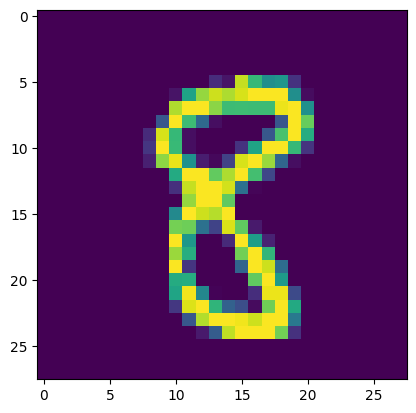

In [82]:
from matplotlib import pyplot as plt

random_choice = np.random.randint(0, 59999)
print(f"One Hot {one_hot_targets_train[random_choice]}")
print(f"Label {np.argmax(one_hot_targets_train[random_choice])}")
plt.imshow(x_train[random_choice][0])
plt.show()

## Accuracy

Selesai! Akurasi Model: 88.75%
--------------------------------------------------


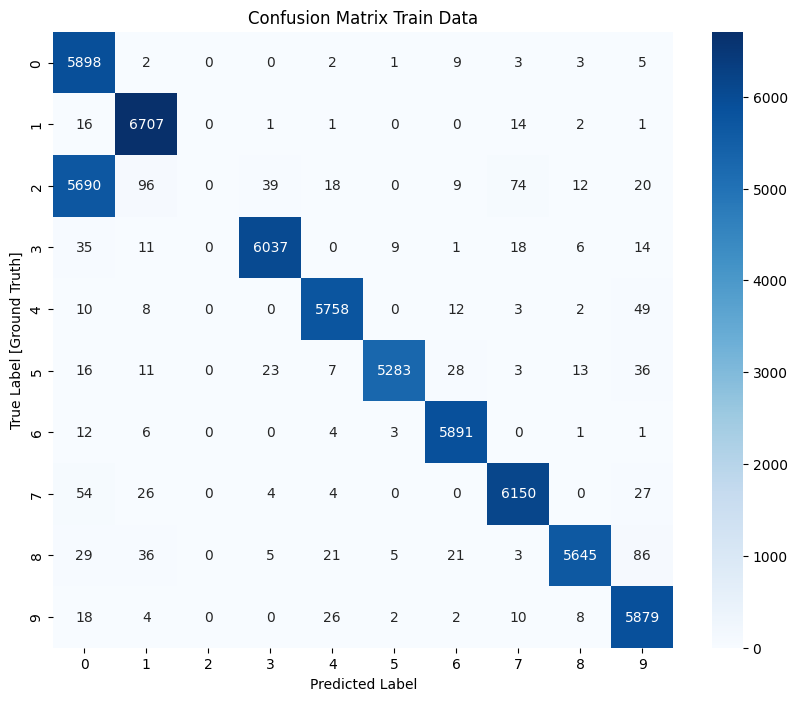

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

all_predictions = []
all_ground_truths = []

for data_idx in range(x_train.shape[0]):
    x = x_train[data_idx].reshape(1, 28, 28)
    
    pred = model_full_predict(x)
    argmax_pred = np.argmax(pred)
    
    g_truth = one_hot_targets_train[data_idx]
    argsmax_g_truth = np.argmax(g_truth)
    
    all_predictions.append(argmax_pred)
    all_ground_truths.append(argsmax_g_truth)

all_predictions = np.array(all_predictions)
all_ground_truths = np.array(all_ground_truths)


accuracy = accuracy_score(all_ground_truths, all_predictions)
print(f"Selesai! Akurasi Model: {accuracy * 100:.2f}%")
print("-" * 50)

cm = confusion_matrix(all_ground_truths, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  xticklabels=list(range(10)),  yticklabels=list(range(10)))

plt.title('Confusion Matrix Train Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label [Ground Truth]')
plt.show()

## Test Data

In [84]:
import pandas as pd

data_file_path_test = "../data/MNIST_CSV/mnist_test.csv"

df_test = pd.read_csv(data_file_path_test)

df_test.head(5)

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
Y_test = df_test.iloc[0:, 0:1]
x_test = df_test.iloc[0:, 1:] / 255

x_test = x_test.to_numpy()
Y_test = Y_test.to_numpy()
print(x_test.shape, Y_test.shape)

(9999, 784) (9999, 1)


In [86]:
x_test = x_test.reshape(9999, 1, 28, 28)

nb_classes = 10
one_hot_targets_test = np.eye(nb_classes)[Y_test]
one_hot_targets_test = one_hot_targets_test.reshape(one_hot_targets_test.shape[0], -1)

In [87]:
x_test.shape, one_hot_targets_test.shape

((9999, 1, 28, 28), (9999, 10))

One Hot [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Label 2


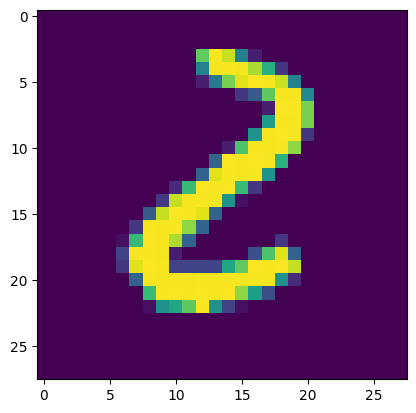

In [88]:
from matplotlib import pyplot as plt

random_choice = np.random.randint(0, 9999)
print(f"One Hot {one_hot_targets_test[random_choice]}")
print(f"Label {np.argmax(one_hot_targets_test[random_choice])}")
plt.imshow(x_test[random_choice][0])
plt.show()

## Accuracy

Selesai! Akurasi Model: 87.96%
--------------------------------------------------


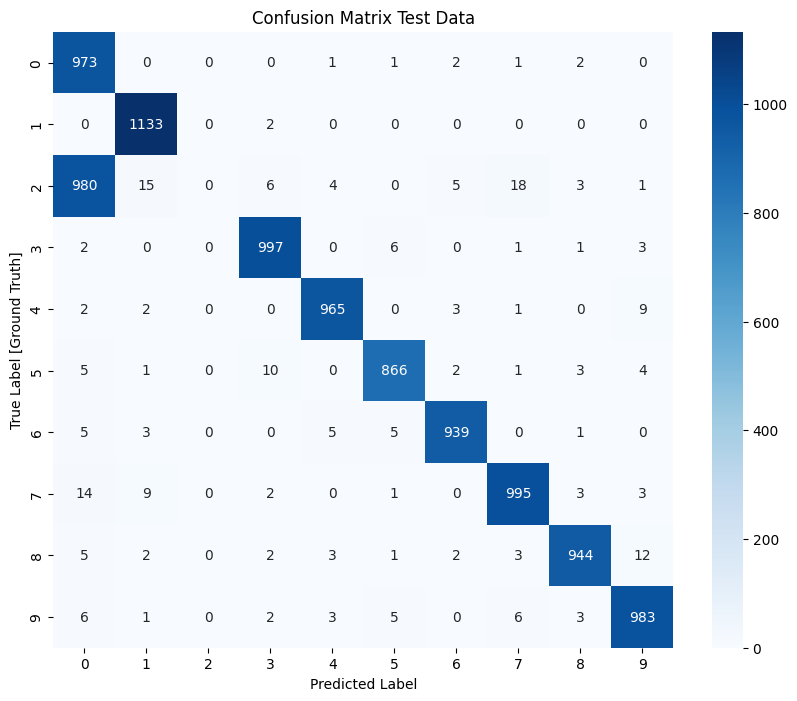

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

all_predictions = []
all_ground_truths = []

for data_idx in range(x_test.shape[0]):
    x = x_test[data_idx].reshape(1, 28, 28)
    
    pred = model_full_predict(x)
    argmax_pred = np.argmax(pred)
    
    g_truth = one_hot_targets_test[data_idx]
    argsmax_g_truth = np.argmax(g_truth)
    
    all_predictions.append(argmax_pred)
    all_ground_truths.append(argsmax_g_truth)

all_predictions = np.array(all_predictions)
all_ground_truths = np.array(all_ground_truths)


accuracy = accuracy_score(all_ground_truths, all_predictions)
print(f"Selesai! Akurasi Model: {accuracy * 100:.2f}%")
print("-" * 50)

cm = confusion_matrix(all_ground_truths, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  xticklabels=list(range(10)),  yticklabels=list(range(10)))

plt.title('Confusion Matrix Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label [Ground Truth]')
plt.show()